# Import Library

In [1]:
# Jalankan cell ini terlebih dahulu, lalu restart runtime jika diminta
!pip install -q PySastrawi gensim pyLDAvis nltk

# Import library standar
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 84.1 MB/s eta 0:00:00


In [35]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# NLP - Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [4]:
# NLP - NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [5]:
# Gensim untuk LDA
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.utils import simple_preprocess

In [6]:
# Visualisasi
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from IPython.display import display

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Import Data

In [36]:
import kagglehub
import os

path = kagglehub.dataset_download("nuricahyono/bibit-investasi")

print(os.listdir(path))

df = pd.read_csv(path + "/Bibit.csv", on_bad_lines='skip')
df.head()

Using Colab cache for faster access to the 'bibit-investasi' dataset.
['Bibit.csv']


,userName,score,at,content
0,Pengguna Google,5,2024-09-07 23:43:52,bagus bgt aplikasinya mudah dimengerti.
1,Pengguna Google,1,2024-09-07 05:14:52,Ganti ke seabank aja bit bibit. Verifikasi jag...
2,Pengguna Google,5,2024-09-07 04:12:14,"mantaps , mudah di pelajari"
3,Pengguna Google,5,2024-09-07 03:20:15,mantab
4,Pengguna Google,1,2024-09-06 12:21:35,Jelek uang saya hilang saat beli eror tapi sal...


# DATA LOADING & STRATIFIED SAMPLING

In [37]:
# --- Validasi Kolom ---
CONTENT_COL = "content"
SCORE_COL   = "score"

assert CONTENT_COL in df.columns, f"Kolom '{CONTENT_COL}' tidak ditemukan!"
assert SCORE_COL   in df.columns, f"Kolom '{SCORE_COL}' tidak ditemukan!"

# --- Data Cleaning Awal ---
df = df[[SCORE_COL, CONTENT_COL]].copy()
df.dropna(subset=[CONTENT_COL], inplace=True)
df[CONTENT_COL] = df[CONTENT_COL].astype(str).str.strip()
df = df[df[CONTENT_COL].str.len() > 5]   # buang ulasan sangat pendek
df.reset_index(drop=True, inplace=True)

print(f"\n Data setelah cleaning awal: {len(df):,} baris")
print(f"\n Distribusi Rating (score):")
print(df[SCORE_COL].value_counts().sort_index())


 Data setelah cleaning awal: 39,340 baris

 Distribusi Rating (score):
score
1     4832
2     1237
3     2145
4     4264
5    26862
Name: count, dtype: int64


In [38]:
# --- Stratified Sampling ---
SAMPLE_SIZE = 2000

# Hitung proporsi tiap rating
rating_counts  = df[SCORE_COL].value_counts()
total_original = len(df)

# Jika data < SAMPLE_SIZE, gunakan semua data
if total_original <= SAMPLE_SIZE:
    df_sample = df.copy()
    print(f"\n  Data ({total_original}) ≤ target sample ({SAMPLE_SIZE}). Menggunakan semua data.")
else:
    # Stratified sampling: proporsi setiap kelas dipertahankan
    df_sample = (
        df.groupby(SCORE_COL, group_keys=False)
          .apply(lambda x: x.sample(
              n=max(1, int(round(len(x) / total_original * SAMPLE_SIZE))),
              random_state=42
          ))
    )
    # Trim jika hasil sedikit melebihi target
    df_sample = df_sample.sample(
        n=min(SAMPLE_SIZE, len(df_sample)),
        random_state=42
    ).reset_index(drop=True)

print(f"\n Stratified Sample berhasil dibuat: {len(df_sample):,} baris")
print(f"\n Distribusi Rating setelah Sampling:")
print(df_sample[SCORE_COL].value_counts().sort_index())


 Stratified Sample berhasil dibuat: 2,000 baris

 Distribusi Rating setelah Sampling:
score
1     246
2      63
3     109
4     217
5    1365
Name: count, dtype: int64


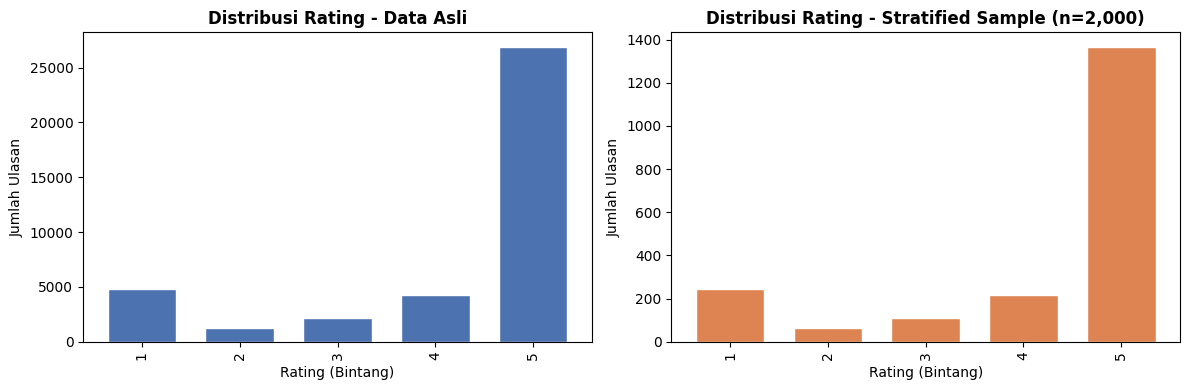

In [39]:
# Visualisasi distribusi rating sebelum & sesudah sampling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[SCORE_COL].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#4C72B0", edgecolor="white", width=0.7
)
axes[0].set_title("Distribusi Rating - Data Asli", fontweight="bold")
axes[0].set_xlabel("Rating (Bintang)")
axes[0].set_ylabel("Jumlah Ulasan")

df_sample[SCORE_COL].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="#DD8452", edgecolor="white", width=0.7
)
axes[1].set_title(f"Distribusi Rating - Stratified Sample (n={len(df_sample):,})", fontweight="bold")
axes[1].set_xlabel("Rating (Bintang)")
axes[1].set_ylabel("Jumlah Ulasan")

plt.tight_layout()
plt.savefig("distribusi_rating.png", dpi=150, bbox_inches="tight")
plt.show()

# TEXT PREPROCESSING

In [40]:
# ==============================================================================
# Pipeline: Case Folding → Cleaning → Tokenizing → Stopword Removal → Stemming
# ==============================================================================

# --- 3.1 Inisialisasi Tools NLP Bahasa Indonesia ---
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stopword = StopWordRemoverFactory()
sastrawi_stopwords = set(factory_stopword.get_stop_words())

In [41]:
custom_stopwords = {
    "aplikasi", "app", "apk", "bibit", "reksadana", "reksa", "dana",
    "fitur", "update", "versi", "baru", "lama", "login", "daftar",
    "yg", "yah", "ya", "iya", "dong", "deh", "sih", "nih", "loh",
    "kan", "kak", "min", "admin", "mohon", "tolong", "please",
    "sangat", "sekali", "banget", "bgt", "bener", "beneran",
    "udah", "sudah", "belum", "masih",
    "jadi", "jg", "juga", "aja", "saja",
    "ref", "kode", "referral", "promo",
}

all_stopwords = sastrawi_stopwords | custom_stopwords

# JANGAN hapus negasi (kecuali 'tidak' jika ingin dikecualikan)
negation_words = {"gak", "ga", "nggak","pemula"} # 'tidak' dihapus dari sini
all_stopwords = all_stopwords - negation_words

slang_dict = {
    "yg": "yang", "dgn": "dengan", "utk": "untuk",
    "krn": "karena", "bgt": "banget",
    "udh": "sudah", "udah": "sudah", "blm": "belum",
    "sm": "sama", "tp": "tapi", "tpi": "tapi",
    "sdh": "sudah", "bs": "bisa", "bsa": "bisa",
    "mk": "maka", "jgn": "jangan", "jd": "jadi",
    "bkn": "bukan", "org": "orang", "lbh": "lebih",
    "tnp": "tanpa", "tlg": "tolong", "msh": "masih",

    "pake": "pakai", "pakee": "pakai", "pakek": "pakai", "pkai": "pakai",
    "dapet": "dapat", "dpt": "dapat",
    "kalo": "kalau", "klo": "kalau", "kl": "kalau",

    "cuan": "untung",
    "rugiin": "rugi",
    "loss": "rugi",

    "bnr": "benar", "bner": "benar", "bener": "benar",

    "gak": "tidak",
    "ga": "tidak",
    "ngk": "tidak",
    "ngga": "tidak",
    "nggak": "tidak",

}

In [42]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\b[a-z0-9]{8,}\b", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_slang(text: str, slang_map: dict) -> str:
    text = re.sub(r"\bpake+\b", "pakai", text)
    text = re.sub(r"\bpkai\b", "pakai", text)
    text = re.sub(r"\bdapet\b", "dapat", text)

    text = re.sub(r"\bkalo\b|\bklo\b|\bkl\b", "kalau", text)

    tokens = text.split()
    tokens = [slang_map.get(t, t) for t in tokens]

    return " ".join(tokens)


def preprocess(text: str) -> list:
    text = clean_text(text)
    text = normalize_slang(text, slang_dict)

    tokens = [t for t in text.split() if len(t) >= 3]
    tokens = [t for t in tokens if t not in all_stopwords]
    tokens = [stemmer.stem(t) for t in tokens]
    tokens = [t for t in tokens if len(t) >= 3 and t not in all_stopwords]

    return tokens

In [43]:
df_sample["tokens"] = df_sample[CONTENT_COL].apply(preprocess)

df_sample = df_sample[df_sample["tokens"].map(len) >= 2].reset_index(drop=True)

print(f"Dokumen valid: {len(df_sample)}")

Dokumen valid: 1207


In [44]:
print(f"\n Contoh Hasil Preprocessing (satu ulasan per rating) :")

# Ambil 1 sampel per rating (reproducible)
sampled_reviews = (
    df_sample
    .assign(token_len=df_sample["tokens"].map(len))
    .query("token_len >= 5")  # 🔥 filter minimal panjang
    .sort_values("token_len", ascending=False)
    .groupby(SCORE_COL)
    .head(1)
    .reset_index(drop=True)
)

# Tampilkan hasil
for i, row in sampled_reviews.iterrows():
    print(f"\n   [Rating {row[SCORE_COL]}] Original: {row[CONTENT_COL][:80]}...")
    print(f"              Tokens   : {row['tokens'][:10]}")


 Contoh Hasil Preprocessing (satu ulasan per rating) :

   [Rating 4] Original: Sbnrnya sya suka dngan konsep nabung saham & obligasi 10 rb-nya. Membantu bnget ...
              Tokens   : ['sbnrnya', 'sya', 'suka', 'dngan', 'konsep', 'nabung', 'saham', 'bnget', 'pnya', 'bnyak']

   [Rating 5] Original: Mudah gampang ucapan di pahami cuma banyak oknum yg tidak bertanggung jawab yg m...
              Tokens   : ['mudah', 'gampang', 'paham', 'oknum', 'rusak', 'rusak', 'lengkap', 'gabung', 'tni', 'polri']

   [Rating 1] Original: Maaf sya harus pamit dr 2019 sya join di bibit tp itu itu aja ngk ada kemajuan t...
              Tokens   : ['maaf', 'sya', 'pamit', 'sya', 'join', 'butuh', 'cepat', 'minggu', 'iming', 'imingkn']

   [Rating 3] Original: Saya investasi di saham sampai sekarang nggak ada cuan2 nya yang ada malah minus...
              Tokens   : ['saham', 'untung', 'minus', 'tunggu', 'untung', 'bas', 'ribu', 'minus', 'puluh', 'ribu']

   [Rating 2] Original: Mo upload foto ktp a

In [45]:
sampled_reviews = (
    df_sample
    .assign(token_len=df_sample["tokens"].map(len))
    .sort_values("token_len", ascending=False)
    .groupby(SCORE_COL)
    .head(3)
)

# Tampilkan hasil
for i, row in sampled_reviews.iterrows():
    print(f"\n   [Rating {row[SCORE_COL]}] Original: {row[CONTENT_COL][:80]}...")
    print(f"              Tokens   : {row['tokens'][:10]}")


   [Rating 4] Original: Sbnrnya sya suka dngan konsep nabung saham & obligasi 10 rb-nya. Membantu bnget ...
              Tokens   : ['sbnrnya', 'sya', 'suka', 'dngan', 'konsep', 'nabung', 'saham', 'bnget', 'pnya', 'bnyak']

   [Rating 5] Original: Mudah gampang ucapan di pahami cuma banyak oknum yg tidak bertanggung jawab yg m...
              Tokens   : ['mudah', 'gampang', 'paham', 'oknum', 'rusak', 'rusak', 'lengkap', 'gabung', 'tni', 'polri']

   [Rating 5] Original: Sangat direkomendasikan untuk pemula. Tapi saya ada saran untuk fitur autopay ju...
              Tokens   : ['saran', 'autopay', 'autopay', 'bank', 'dompet', 'digital', 'utama', 'bank', 'dompet', 'digital']

   [Rating 1] Original: Maaf sya harus pamit dr 2019 sya join di bibit tp itu itu aja ngk ada kemajuan t...
              Tokens   : ['maaf', 'sya', 'pamit', 'sya', 'join', 'butuh', 'cepat', 'minggu', 'iming', 'imingkn']

   [Rating 1] Original: APK ribet jual saham gk masuk ke rekening dari tgl 7 dan sampe 15. 

In [46]:
from collections import Counter

all_tokens_flat = [t for tokens in df_sample["tokens"] for t in tokens]

print(f"\n Statistik Token:")
print(f"   Total token         : {len(all_tokens_flat):,}")
print(f"   Vocabulari unik     : {len(set(all_tokens_flat)):,}")
print(f"   Rata-rata token/doc : {len(all_tokens_flat)/len(df_sample):.1f}")


 Statistik Token:
   Total token         : 5,870
   Vocabulari unik     : 1,563
   Rata-rata token/doc : 4.9



10 Kata Paling Sering Muncul dan Jumlahnya:
- pakai: 174
- bagus: 157
- mudah: 143
- moga: 101
- referal: 81
- ajar: 79
- uang: 69
- nabung: 68
- coba: 58
- bank: 57


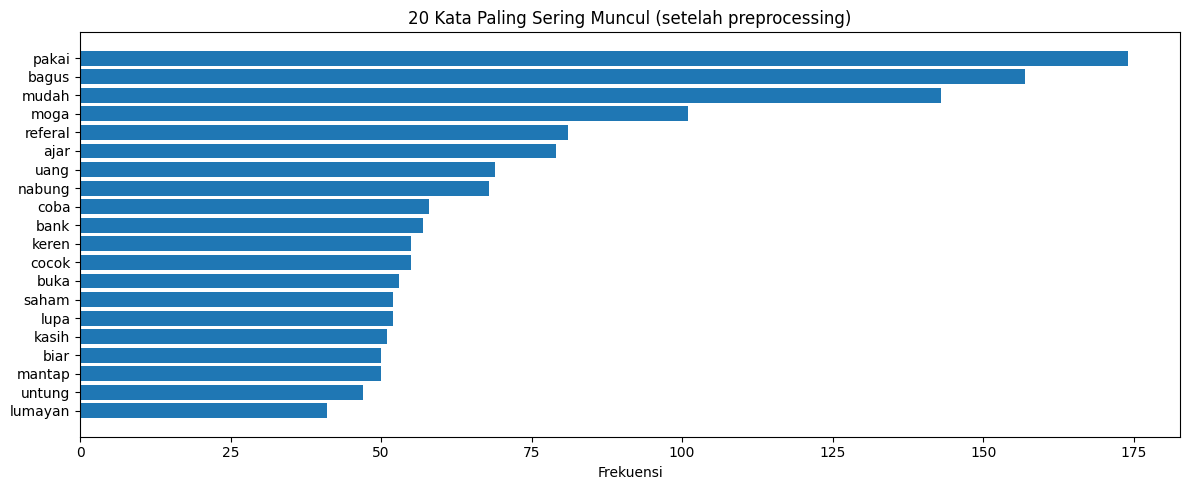

In [47]:
# Visualisasi 20 kata paling sering muncul
# Hitung semua token
counter = Counter(all_tokens_flat)

# Exclude kata tertentu
exclude_words = {"tidak"}

filtered_counter = Counter({
    k: v for k, v in counter.items()
    if k not in exclude_words
})

# Ambil top words dari hasil filter
top_words = filtered_counter.most_common(20)

print("\n10 Kata Paling Sering Muncul dan Jumlahnya:")
for word, freq in top_words[:10]:
    print(f"- {word}: {freq}")

# Plot
words, freqs = zip(*top_words)

plt.figure(figsize=(12, 5))
plt.barh(words[::-1], freqs[::-1])
plt.title("20 Kata Paling Sering Muncul (setelah preprocessing)")
plt.xlabel("Frekuensi")
plt.tight_layout()
plt.show()

# Vectorization

In [48]:
# ==============================================================================
# Menggunakan Gensim untuk representasi numerik dokumen
# ==============================================================================

# --- 4.1 Bangun Dictionary ---
# Dictionary memetakan setiap kata ke ID unik
dictionary = corpora.Dictionary(df_sample["tokens"])

print(f" Dictionary sebelum filtering:")
print(f"   Jumlah term unik: {len(dictionary):,}")

# Filter ekstrem:
# - no_below: hapus kata yang muncul di < N dokumen (sangat jarang)
# - no_above: hapus kata yang muncul di > X% dokumen (terlalu umum)
# - keep_n  : pertahankan paling banyak N kata teratas
dictionary.filter_extremes(no_below=5, no_above=0.85, keep_n=5000)

print(f"\n Dictionary setelah filtering (no_below=5, no_above=0.85):")
print(f"   Jumlah term unik: {len(dictionary):,}")

# --- 4.2 Bangun Corpus (Bag of Words) ---
# Setiap dokumen direpresentasikan sebagai list of (word_id, count)
corpus = [dictionary.doc2bow(tokens) for tokens in df_sample["tokens"]]

print(f"\n Corpus berhasil dibuat!")
print(f"   Jumlah dokumen: {len(corpus):,}")
print(f"   Contoh corpus[0]: {corpus[0][:5]} ...")  # 5 pasang pertama

 Dictionary sebelum filtering:
   Jumlah term unik: 1,563

 Dictionary setelah filtering (no_below=5, no_above=0.85):
   Jumlah term unik: 220

 Corpus berhasil dibuat!
   Jumlah dokumen: 1,207
   Contoh corpus[0]: [(0, 1), (1, 1), (2, 1)] ...


# LDA Modelling

In [49]:
# ==============================================================================
# Melatih model LDA dengan evaluasi jumlah topik optimal
# ==============================================================================

# --- 5.1 Fungsi Hitung Coherence Score ---
def compute_coherence(num_topics: int, corpus, dictionary, texts,
                      passes=15, workers=2) -> float:
    """Melatih LDA dan mengembalikan Coherence Score (Cv)."""
    model = LdaModel(
        corpus       = corpus,
        id2word      = dictionary,
        num_topics   = num_topics,
        random_state = 42,
        passes       = passes,
        alpha        = "auto",    # prior distribusi dokumen-topik (adaptif)
        eta          = "auto",    # prior distribusi topik-kata (adaptif)
        per_word_topics = True,
    )
    cm_model = CoherenceModel(
        model      = model,
        texts      = texts,
        dictionary = dictionary,
        coherence  = "c_v"
    )
    return cm_model.get_coherence(), model

In [50]:
# --- 5.2 Evaluasi Jumlah Topik Optimal (range 3–10) ---

topic_range   = range(3, 11)    # uji 3 s.d. 10 topik
coherence_vals = []
models_dict    = {}

for n in topic_range:
    score, model = compute_coherence(
        num_topics = n,
        corpus     = corpus,
        dictionary = dictionary,
        texts      = df_sample["tokens"].tolist(),
        passes     = 15,
    )
    coherence_vals.append(score)
    models_dict[n] = model
    print(f"   Topik = {n:2d}  |  Coherence (Cv) = {score:.4f}")

   Topik =  3  |  Coherence (Cv) = 0.3762
   Topik =  4  |  Coherence (Cv) = 0.4188
   Topik =  5  |  Coherence (Cv) = 0.3874
   Topik =  6  |  Coherence (Cv) = 0.3790
   Topik =  7  |  Coherence (Cv) = 0.3902
   Topik =  8  |  Coherence (Cv) = 0.4264
   Topik =  9  |  Coherence (Cv) = 0.4540
   Topik = 10  |  Coherence (Cv) = 0.4548


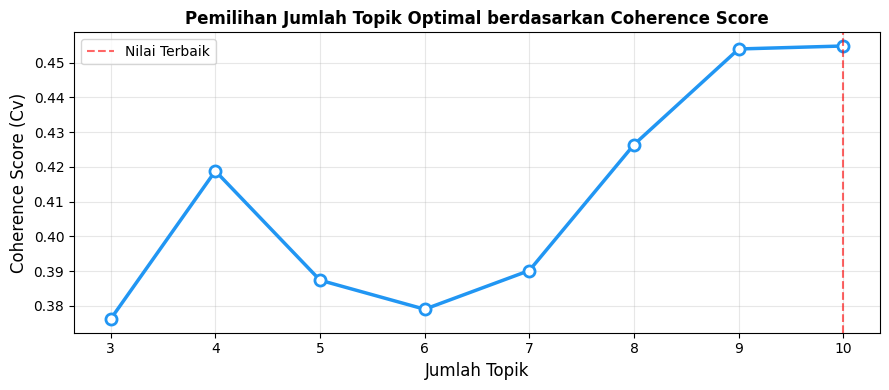

In [51]:
# Plot Coherence Score
plt.figure(figsize=(9, 4))
plt.plot(list(topic_range), coherence_vals, "o-", color="#2196F3",
         linewidth=2.5, markersize=8, markerfacecolor="white", markeredgewidth=2)
plt.axvline(x=list(topic_range)[coherence_vals.index(max(coherence_vals))],
            color="red", linestyle="--", alpha=0.6, label="Nilai Terbaik")
plt.xlabel("Jumlah Topik", fontsize=12)
plt.ylabel("Coherence Score (Cv)", fontsize=12)
plt.title("Pemilihan Jumlah Topik Optimal berdasarkan Coherence Score", fontweight="bold")
plt.xticks(list(topic_range))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("coherence_score.png", dpi=150, bbox_inches="tight")
plt.show()

In [52]:
# Pilih jumlah topik dengan coherence tertinggi
best_n_topics = list(topic_range)[coherence_vals.index(max(coherence_vals))]
best_score    = max(coherence_vals)
print(f"\n Jumlah Topik Optimal : {best_n_topics} topik")
print(f"   Coherence Score (Cv) : {best_score:.4f}")


 Jumlah Topik Optimal : 10 topik
   Coherence Score (Cv) : 0.4548


In [53]:
# --- 5.3 Training Model LDA Final ---

lda_model = LdaModel(
    corpus          = corpus,
    id2word         = dictionary,
    num_topics      = best_n_topics,
    random_state    = 42,
    passes          = 20,            # lebih banyak iterasi → lebih stabil
    alpha           = "auto",
    eta             = "auto",
    per_word_topics = True,
    chunksize       = 200,           # jumlah dokumen per chunk saat training
    update_every    = 1,
)

print(" Model LDA final berhasil dilatih!")

 Model LDA final berhasil dilatih!


# MODEL EVALUATION

In [54]:
# ==============================================================================
# Coherence Score (Cv) dan Perplexity sebagai metrik validasi
# ==============================================================================

# Coherence Score model final
coherence_model = CoherenceModel(
    model      = lda_model,
    texts      = df_sample["tokens"].tolist(),
    dictionary = dictionary,
    coherence  = "c_v"
)
coherence_final = coherence_model.get_coherence()

# Perplexity (semakin rendah semakin baik — mengukur "kebingungan" model)
perplexity = lda_model.log_perplexity(corpus)

print("\n" + "="*55)
print("       EVALUASI MODEL LDA")
print("="*55)
print(f"  Jumlah Topik        : {best_n_topics}")
print(f"  Coherence Score(Cv) : {coherence_final:.4f}   (target > 0.40)")
print(f"  Log Perplexity      : {perplexity:.4f}   (makin rendah makin baik)")
print("="*55)
print("\n Interpretasi Coherence Score:")
if   coherence_final >= 0.60: print("   Sangat Baik (≥ 0.60) — Topik sangat koheren")
elif coherence_final >= 0.50: print("   Baik        (0.50–0.59) — Topik cukup koheren")
elif coherence_final >= 0.40: print("   Cukup       (0.40–0.49) — Topik relatif koheren")
else:                          print("   Perlu Review (< 0.40) — Coba jumlah topik berbeda")


       EVALUASI MODEL LDA
  Jumlah Topik        : 10
  Coherence Score(Cv) : 0.5477   (target > 0.40)
  Log Perplexity      : -5.3341   (makin rendah makin baik)

 Interpretasi Coherence Score:
   Baik        (0.50–0.59) — Topik cukup koheren


# INTERACTIVE VISUALIZATION (pyLDAvis) & Word Cloud


       WORD CLOUD UNTUK SETIAP TOPIK LDA


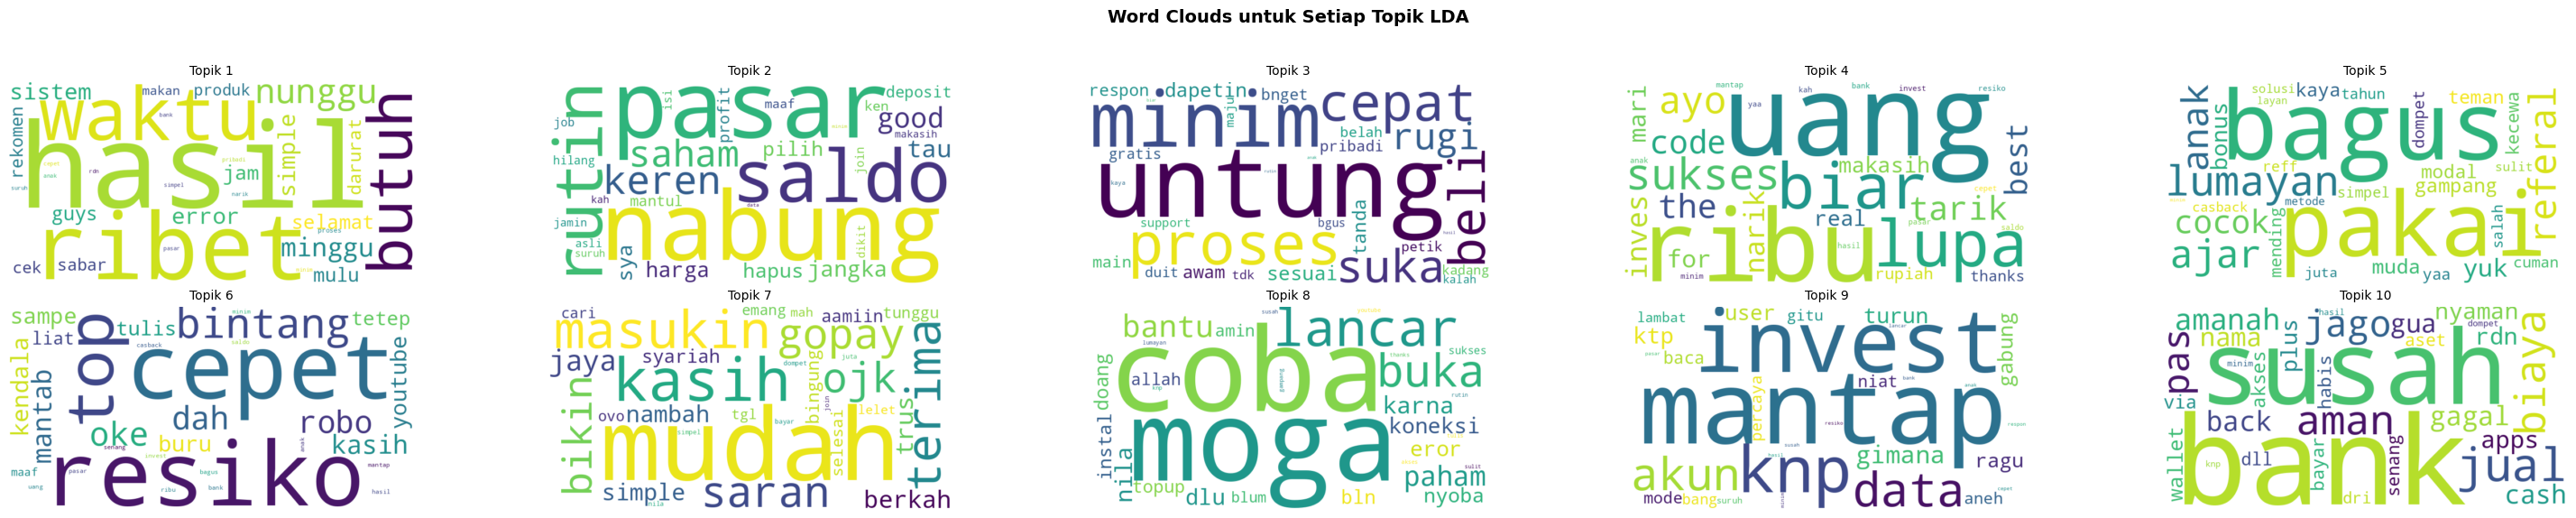


✅ Word clouds berhasil dibuat untuk semua topik dalam tata letak grid!


In [55]:
from wordcloud import WordCloud
import math

# ==============================================================================
# Visualisasi Word Cloud untuk Setiap Topik
# ==============================================================================

print("\n" + "="*50)
print("       WORD CLOUD UNTUK SETIAP TOPIK LDA")
print("="*50)

# Atur parameter WordCloud
wc = WordCloud(background_color="white",
               max_words=50,
               width=800, # Ukuran asli untuk WordCloud, akan disesuaikan saat plot
               height=400, # Ukuran asli untuk WordCloud, akan disesuaikan saat plot
               colormap='viridis')

# Menghitung jumlah baris dan kolom untuk grid (transposed)
rows = 2 # Atur jumlah baris menjadi 2
cols = math.ceil(best_n_topics / rows) # Hitung jumlah kolom berdasarkan jumlah topik dan baris

# Buat figure dan subplots
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 3), constrained_layout=True)
axes = axes.flatten() # Meratakan array axes agar mudah diiterasi

# Generate word cloud untuk setiap topik
for i, topic_words in enumerate(lda_model.show_topics(num_topics=best_n_topics, num_words=30, formatted=False)):
    if i < len(axes):
        word_weights = {word: weight for word, weight in topic_words[1]}
        wc.generate_from_frequencies(word_weights)

        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].set_title(f"Topik {i+1}", fontsize=10) # Ukuran font judul topik
        axes[i].axis("off")

# Sembunyikan subplot yang tidak terpakai jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Word Clouds untuk Setiap Topik LDA", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Sesuaikan layout untuk suptitle
plt.savefig("wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Word clouds berhasil dibuat untuk semua topik dalam tata letak grid!")

In [56]:
# ==============================================================================
# Visualisasi distribusi topik dan kata kunci per topik
# ==============================================================================

# Siapkan visualisasi
pyLDAvis.enable_notebook()

lda_vis = gensimvis.prepare(
    topic_model  = lda_model,
    corpus       = corpus,
    dictionary   = dictionary,
    sort_topics  = False,   # pertahankan urutan topik asli
    mds          = "mmds",  # MultiDimensional Scaling (mmds lebih cepat)
)

# Tampilkan di notebook (interaktif)
display(lda_vis)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.008120  0.080777       1        1   5.615454
1      0.050456 -0.402668       2        1  11.678270
2     -0.306815 -0.116679       3        1   8.229524
3     -0.226290  0.381045       4        1   9.003498
4      0.376057 -0.301833       5        1  23.036615
5      0.307265 -0.037129       6        1   4.983562
6      0.100235  0.411898       7        1  10.400958
7     -0.259827 -0.377862       8        1  10.405076
8     -0.426586  0.120716       9        1   7.195913
9      0.377386  0.241735      10        1   9.451130, topic_info=       Term        Freq       Total Category  logprob  loglift
16    mudah  157.000000  157.000000  Default  30.0000  30.0000
33    bagus  227.000000  227.000000  Default  29.0000  29.0000
32    pakai  199.000000  199.000000  Default  28.0000  28.0000
22     uang  105.000000  105.000000  Default  27.0000  27.0000
14     coba  109.000000  109.000000  Default  26.0000  26.0000
..      ...         ...         ...      ...      ...      ...
160   layan    0.094853    3.577733  Topic10  -8.2592  -1.2711
73    minim    0.094908   43.826564  Topic10  -8.2586  -3.7760
104     knp    0.094889   39.383283  Topic10  -8.2588  -3.6694
213  dompet    0.094885    8.712670  Topic10  -8.2589  -2.1608
182   hasil    0.094876   48.145410  Topic10  -8.2590  -3.8704

[402 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
81        7  0.856859   aamiin
27        5  0.986725     ajar
204      10  0.771804    akses
114       9  0.947857     akun
143       8  0.890267    allah
...     ...       ...      ...
96        1  0.946791    waktu
208      10  0.859545   wallet
118       5  0.965188      yaa
129       6  0.763533  youtube
43        5  0.970385      yuk

[226 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [57]:
# Simpan sebagai file HTML untuk laporan
pyLDAvis.save_html(lda_vis, "lda_visualization_bibit.html")
print("Visualisasi interaktif berhasil dibuat!")
print("Disimpan sebagai: lda_visualization_bibit.html")

Visualisasi interaktif berhasil dibuat!
Disimpan sebagai: lda_visualization_bibit.html


# OUTPUT INTERPRETATION

In [58]:
# ==============================================================================
# Tampilkan kata kunci teratas tiap topik untuk pemberian label tema
# ==============================================================================

print("\n" + "="*65)
print("         TOP KATA KUNCI PER TOPIK — HASIL LDA")
print("="*65)

TOP_N_WORDS = 15   # tampilkan 15 kata teratas per topik

topic_keywords = {}
for topic_id in range(best_n_topics):
    top_words_raw = lda_model.show_topic(topic_id, topn=TOP_N_WORDS)
    words_only    = [w for w, _ in top_words_raw]
    topic_keywords[topic_id] = top_words_raw

    print(f"\n TOPIK {topic_id + 1}")
    print(f"   {'Kata':<20} {'Bobot':>8}")
    print(f"   {'-'*30}")
    for word, weight in top_words_raw:
        bar = "█" * int(weight * 200)
        print(f"   {word:<20} {weight:.4f}  {bar}")


         TOP KATA KUNCI PER TOPIK — HASIL LDA

 TOPIK 1
   Kata                    Bobot
   ------------------------------
   hasil                0.2176  ███████████████████████████████████████████
   ribet                0.1221  ████████████████████████
   waktu                0.0886  █████████████████
   butuh                0.0590  ███████████
   nunggu               0.0498  █████████
   minggu               0.0493  █████████
   simple               0.0390  ███████
   error                0.0367  ███████
   sistem               0.0366  ███████
   jam                  0.0288  █████
   selamat              0.0275  █████
   guys                 0.0260  █████
   mulu                 0.0259  █████
   darurat              0.0232  ████
   rekomen              0.0207  ████

 TOPIK 2
   Kata                    Bobot
   ------------------------------
   nabung               0.1687  █████████████████████████████████
   pasar                0.1628  ████████████████████████████████
   saldo   

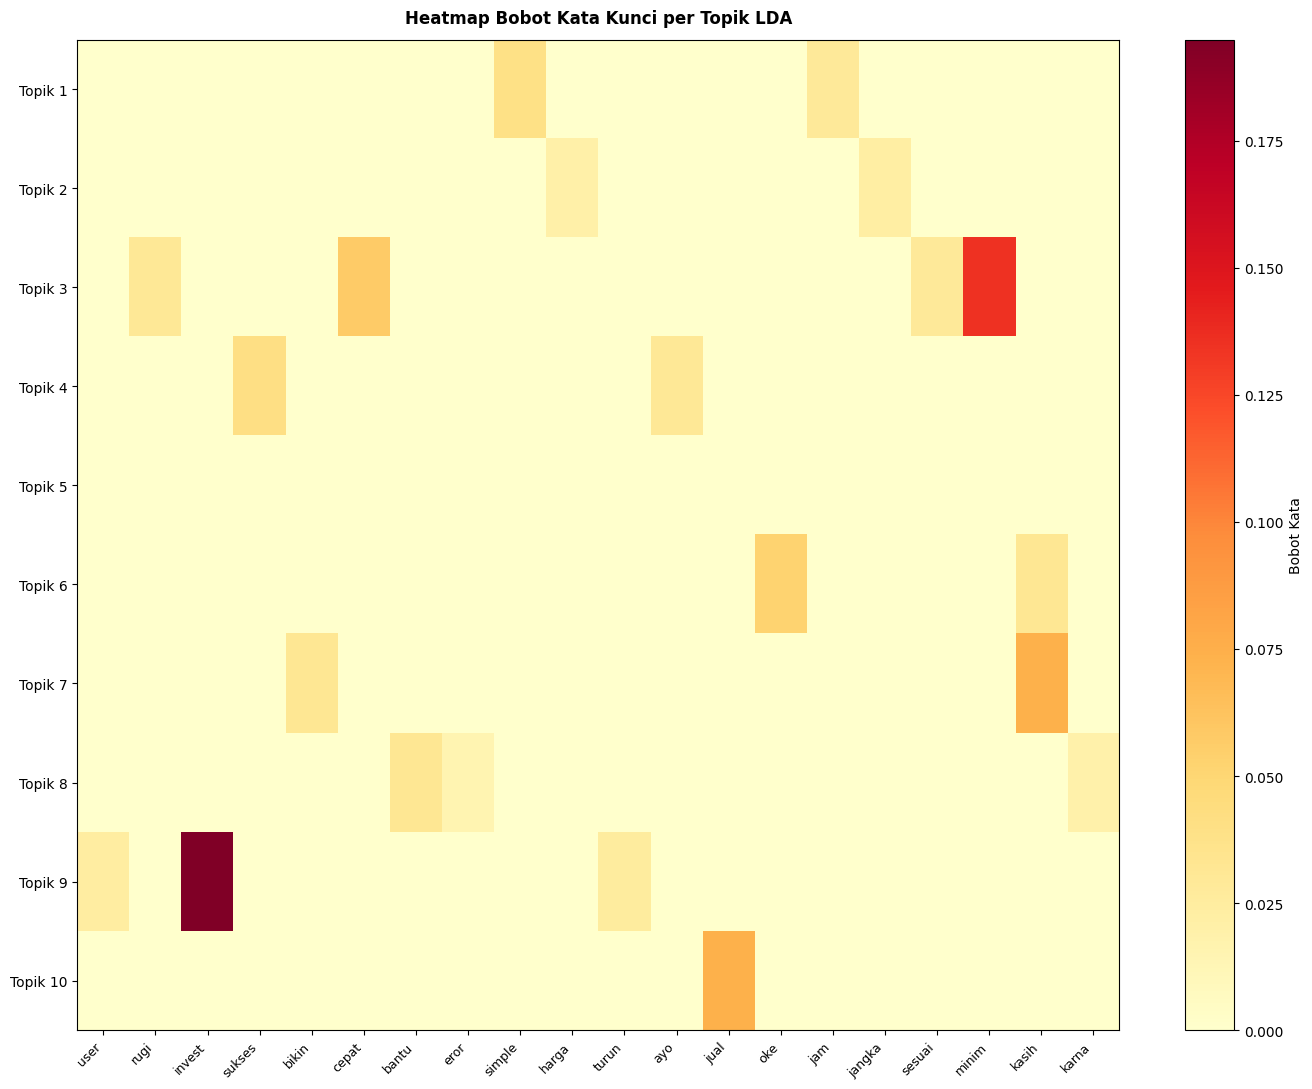

In [59]:
# --- Visualisasi Heatmap Kata Kunci ---

# Ambil 10 kata teratas tiap topik untuk heatmap
top10_per_topic = {}
for t in range(best_n_topics):
    top10_per_topic[t] = dict(lda_model.show_topic(t, topn=10))

# Union semua kata unik (maks 20 kata untuk keterbacaan)
all_kw   = list(set(w for d in top10_per_topic.values() for w in d.keys()))[:20]
heatmap  = np.array([[top10_per_topic[t].get(w, 0) for w in all_kw]
                      for t in range(best_n_topics)])

fig, ax = plt.subplots(figsize=(14, best_n_topics * 0.9 + 2))
im = ax.imshow(heatmap, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(all_kw)))
ax.set_xticklabels(all_kw, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(best_n_topics))
ax.set_yticklabels([f"Topik {i+1}" for i in range(best_n_topics)])
ax.set_title("Heatmap Bobot Kata Kunci per Topik LDA", fontweight="bold", pad=12)
plt.colorbar(im, label="Bobot Kata")
plt.tight_layout()
plt.savefig("heatmap_topik.png", dpi=150, bbox_inches="tight")
plt.show()

In [60]:
# --- Distribusi Topik per Dokumen ---

def get_dominant_topic(lda_model, bow):
    """Mengembalikan topik dominan dan probabilitasnya untuk satu dokumen."""
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0.0)
    dominant   = max(topic_dist, key=lambda x: x[1])
    return dominant[0], dominant[1]

df_sample["dominant_topic"], df_sample["topic_prob"] = zip(
    *[get_dominant_topic(lda_model, bow) for bow in corpus]
)
df_sample["dominant_topic_label"] = df_sample["dominant_topic"].apply(
    lambda x: f"Topik {x+1}"
)

print(f"\n Distribusi Topik Dominan pada Dokumen:")
topic_dist_df = (
    df_sample["dominant_topic_label"]
    .value_counts()
    .reset_index()
    .rename(columns={"dominant_topic_label": "Topik", "count": "Jumlah Dokumen"})
    .sort_values("Topik")
)
topic_dist_df["Persentase (%)"] = (
    topic_dist_df["Jumlah Dokumen"] / len(df_sample) * 100
).round(2)
print(topic_dist_df.to_string(index=False))


 Distribusi Topik Dominan pada Dokumen:
   Topik  Jumlah Dokumen  Persentase (%)
 Topik 1              34            2.82
Topik 10              82            6.79
 Topik 2             135           11.18
 Topik 3              55            4.56
 Topik 4              76            6.30
 Topik 5             482           39.93
 Topik 6              28            2.32
 Topik 7             103            8.53
 Topik 8             151           12.51
 Topik 9              61            5.05


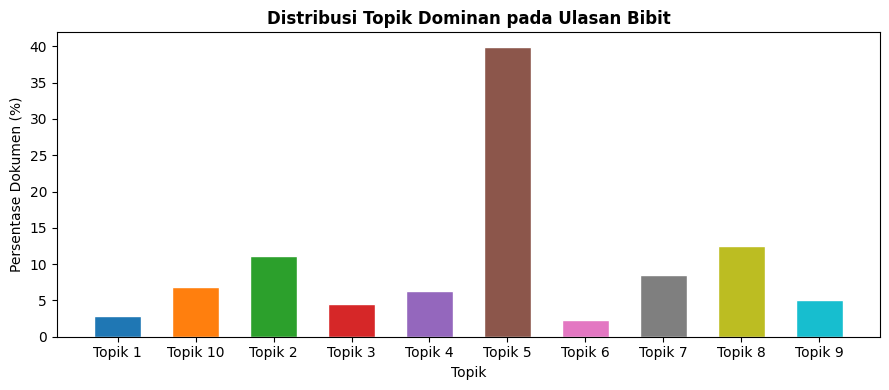

In [61]:
# Bar chart distribusi topik
plt.figure(figsize=(9, 4))
plt.bar(topic_dist_df["Topik"], topic_dist_df["Persentase (%)"],
        color=cm.tab10(np.linspace(0, 1, best_n_topics)),
        edgecolor="white", width=0.6)
plt.xlabel("Topik")
plt.ylabel("Persentase Dokumen (%)")
plt.title("Distribusi Topik Dominan pada Ulasan Bibit", fontweight="bold")
plt.tight_layout()
plt.savefig("distribusi_topik.png", dpi=150, bbox_inches="tight")
plt.show()

In [62]:
# ==============================================================================
# BAGIAN 9: EXPORT HASIL
# Simpan hasil akhir ke CSV untuk keperluan laporan
# ==============================================================================

# Tambahkan kolom kata kunci topik ke dataframe
kw_lookup = {
    t: ", ".join([w for w, _ in kws[:6]])
    for t, kws in topic_keywords.items()
}
df_sample["top_keywords"] = df_sample["dominant_topic"].map(kw_lookup)

# Simpan ke CSV
output_cols = [SCORE_COL, CONTENT_COL, "tokens",
               "dominant_topic_label", "topic_prob", "top_keywords"]
df_sample[output_cols].to_csv("hasil_lda_bibit.csv", index=False)

print("\n" + "="*65)
print("  ✅ SELESAI! Semua output telah disimpan:")
print("="*65)
print("  📊 distribusi_rating.png    — distribusi rating sebelum/sesudah sampling")
print("  📊 top20_words.png          — 20 kata paling sering")
print("  📊 coherence_score.png      — evaluasi jumlah topik optimal")
print("  🌐 lda_visualization_bibit.html — visualisasi pyLDAvis interaktif")
print("  📊 heatmap_topik.png        — heatmap bobot kata per topik")
print("  📊 distribusi_topik.png     — distribusi topik dominan")
print("  📄 hasil_lda_bibit.csv      — data lengkap + label topik per dokumen")
print("="*65)
print(f"\n  Model : LDA ({best_n_topics} Topik)")
print(f"  Coherence Score (Cv) : {coherence_final:.4f}")
print(f"  Log Perplexity       : {perplexity:.4f}")
print(f"  Dokumen dianalisis   : {len(df_sample):,}")
print("="*65)
print("\n📝 LANGKAH SELANJUTNYA UNTUK LAPORAN UTS:")
print("  1. Buka lda_visualization_bibit.html di browser")
print("  2. Klik tiap bubble topik dan amati kata kuncinya")
print("  3. Beri label tema pada tiap topik (lihat output Bagian 8)")
print("  4. Analisis topik dominan pada rating rendah vs tinggi")
print("  5. Sertakan Coherence Score sebagai bukti validasi model")


  ✅ SELESAI! Semua output telah disimpan:
  📊 distribusi_rating.png    — distribusi rating sebelum/sesudah sampling
  📊 top20_words.png          — 20 kata paling sering
  📊 coherence_score.png      — evaluasi jumlah topik optimal
  🌐 lda_visualization_bibit.html — visualisasi pyLDAvis interaktif
  📊 heatmap_topik.png        — heatmap bobot kata per topik
  📊 distribusi_topik.png     — distribusi topik dominan
  📄 hasil_lda_bibit.csv      — data lengkap + label topik per dokumen

  Model : LDA (10 Topik)
  Coherence Score (Cv) : 0.5477
  Log Perplexity       : -5.3341
  Dokumen dianalisis   : 1,207

📝 LANGKAH SELANJUTNYA UNTUK LAPORAN UTS:
  1. Buka lda_visualization_bibit.html di browser
  2. Klik tiap bubble topik dan amati kata kuncinya
  3. Beri label tema pada tiap topik (lihat output Bagian 8)
  4. Analisis topik dominan pada rating rendah vs tinggi
  5. Sertakan Coherence Score sebagai bukti validasi model
